In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Images Shape  :", x_test.shape)
print("Testing Labels Shape  :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


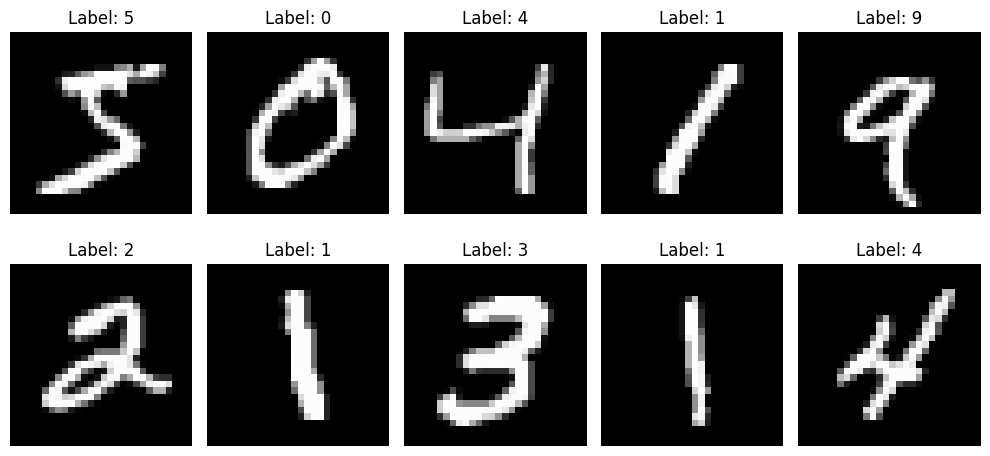

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("New Training Shape :", x_train.shape)
print("New Testing Shape  :", x_test.shape)

New Training Shape : (60000, 28, 28, 1)
New Testing Shape  : (10000, 28, 28, 1)


In [5]:
model = Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu',input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

c:\Users\Hari\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [8]:
history = model.fit(x_train,y_train,epochs=10,validation_split=0.2,batch_size=64)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.9444 - loss: 0.1807 - val_accuracy: 0.9820 - val_loss: 0.0605
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9842 - loss: 0.0523 - val_accuracy: 0.9863 - val_loss: 0.0482
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9881 - loss: 0.0364 - val_accuracy: 0.9890 - val_loss: 0.0386
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.9910 - loss: 0.0278 - val_accuracy: 0.9874 - val_loss: 0.0416
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.9935 - loss: 0.0203 - val_accuracy: 0.9893 - val_loss: 0.0387
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9950 - loss: 0.0162 - val_accuracy: 0.9859 - val_loss: 0.0505
Epoch 7/10
387/750 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9966 - loss: 0.0110

KeyboardInterrupt: 

In [9]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9922 - loss: 0.0282
Test Loss     : 0.02820166014134884
Test Accuracy : 0.9922000169754028


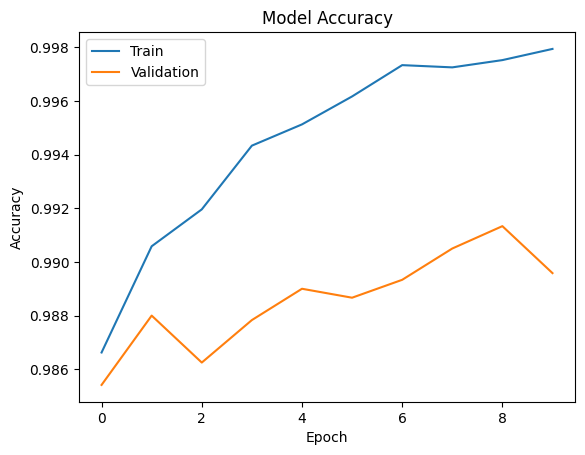

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

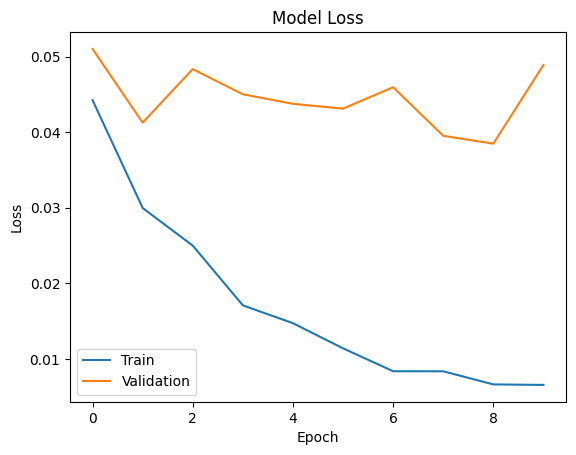

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [31]:
predictions = model.predict(x_test)
predicted_label = np.argmax(predictions[0])
print("Predicted Label :", predicted_label)
print("Actual Label    :", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Predicted Label : 7
Actual Label    : 7


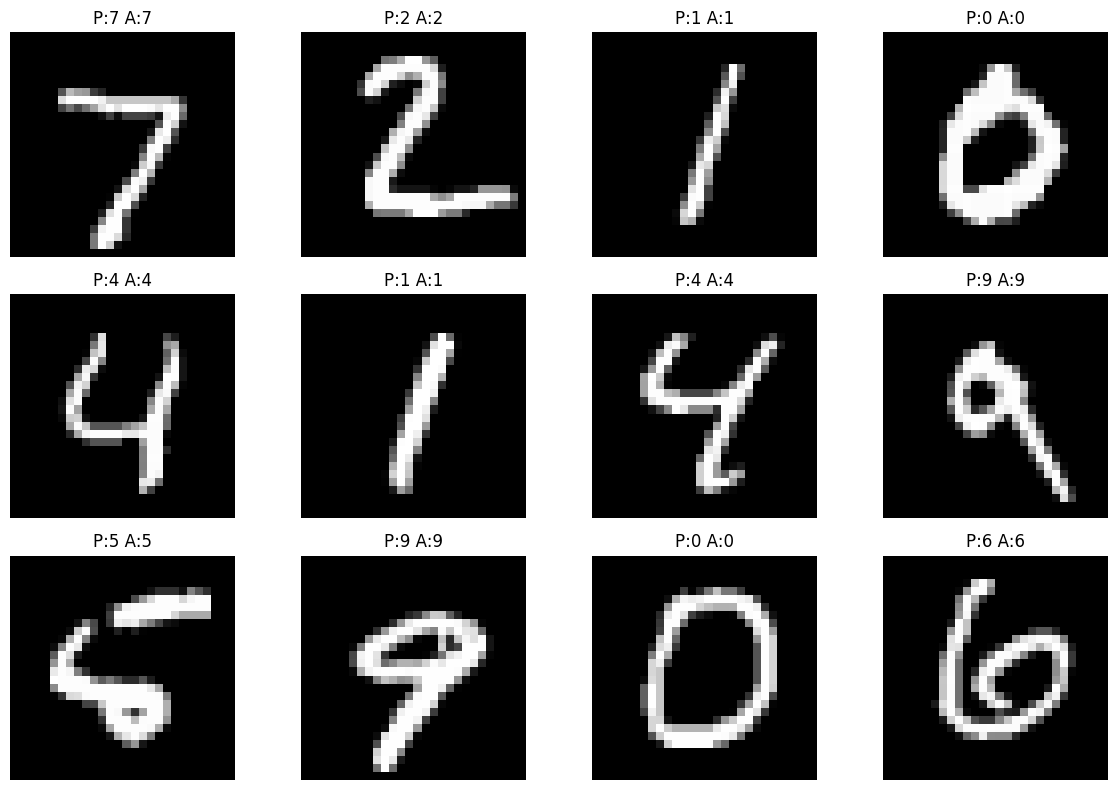

In [32]:
plt.figure(figsize=(12,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    predicted = np.argmax(predictions[i])
    plt.title(f"P:{predicted} A:{y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()